In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [2]:
path=keras.datasets.mnist

datasets is the module(folder) inside the keras and mnist is One specific dataset inside that folder.

“Go to Keras → open datasets → select MNIST dataset”

In [3]:
(x_train,y_train),(x_test,y_test)=path.load_data()

download data
return training & testing sets. This means Load MNIST dataset and split it into:


In [4]:
len(x_train)

60000

In [5]:
len(x_test)

10000

In [6]:
x_train[0].shape

(28, 28)

In [7]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

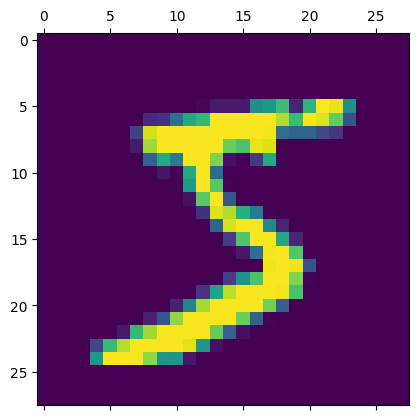

In [8]:
plt.matshow(x_train[0])

matshow() -> visualizes the 2D array as an image

In [9]:
y_train[0]

np.uint8(5)

In [10]:
x_train_flattened=x_train.reshape(len(x_train),28*28)


x_train_flattened=x_train.reshape(60000, 784)

In [11]:
x_train=x_train/255
y_train=y_train/255

Normalization is done.
Before: values in rupees (0–255)
After: values in percentage (0–1)

Easier for the model to understand patterns

In [12]:
x_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [13]:
x_train_flattened=x_train.reshape(len(x_train),28*28)


x_train_flattened=x_train.reshape(60000, 784)

[ [1,2,...], [....], ... ] -> [1, 2, 3, ..., 784]

Dense layer works like this: 
output = w1*x1 + w2*x2 + ... + w784*x784
so we we need 1d input like this flattened
x1, x2, ..., x784 (1D inputs)

Flattening is required ONLY for:

Dense (fully connected networks)

 NOT required for:

CNN (Convolutional Neural Networks)

Simple Neural Network,jaha esari flattened garyo , 28*28 lai 784 input ma 

<img src="digits_nn.jpg" />

In [14]:
model=keras.Sequential([
    keras.layers.Dense(10,input_shape=(784,), activation='sigmoid')])

c:\Users\Admin HP\OneDrive\Desktop\MyDataScienceProject\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


This code creates a very simple neural network model ,that is single layer

It takes input data of size 784 (like an image with 784 pixels)
Passes it through one layer
Produces 10 outputs (for 10 classes, like digits 0–9)

Sequential Model means
Layers are arranged one after another

Like this way :Input → Layer1 → Layer2 → Layer3 → Output

use of [] kinaki , it can store list of layers like this
keras.Sequential([
    Layer1,
    Layer2,
    Layer3
])

Dense
= fully connected layer
(each neuron connects to all inputs). 10
= number of neurons (output units)

activation='sigmoid'
= function applied to output

Converts values between 0 and 1

In [15]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

compile()
= prepares model for training. ra 

Optimizer = how the model updates its weights

What Adam does:
Adjusts weights step-by-step
Uses gradients (error direction)
Learns fast + efficiently
“How big a step should I take to reduce error?”

Loss = how wrong the model is .sparse_categorical_crossentropy
= used for multi-class classification.metrics
= how performance is measured.accuracy
= percentage of correct predictions

y = 5, 2, 9 ...

 That’s called sparse labels (just numbers, not vectors)

In [16]:
model.fit(x_train_flattened, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.0986 - loss: 0.0241
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0987 - loss: 3.9782e-04
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.0987 - loss: 1.2482e-04
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.0987 - loss: 4.7231e-05
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0987 - loss: 1.9037e-05
